# PEMS-XGBoost NOX — evaluación walk-forward FINAL R1F_STD

**Propósito:** consumir sin cambios la configuración FROZEN producida por
`07_XGBoost_NOX_WF_OPT - R1_POC_EFFICIENT.ipynb`, entrenar diez modelos con
DEV 2011–2014 completo y evaluar una sola vez la frontera prospectiva 2015.

**Entradas:** `WF_PROTOCOL_R1`, `BEST_CONFIG`, política final y manifiesto
FROZEN del notebook OPT. **Salidas:** modelos UBJ, predicciones 2015,
métricas por semilla y ensamble, diagnósticos por decil, importancia,
complejidad, almacenamiento y latencia CPU.

**Estado:** FINAL / STANDARDIZED. No contiene Optuna ni reabre decisiones.
XGBoost es exclusivamente data-driven; no aplica restricciones monotónicas,
física, sintéticos, escalamiento de X ni clipping de predicciones.

El CSV 2015 no se abre ni se hashea hasta que los diez modelos y sus sidecars
han sido persistidos y autenticados por `PRE_TEST_GATE`.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, rutas y utilidades |
| SEC-02 | autenticación de protocolo WF y OPT FROZEN |
| SEC-03 | carga exclusiva de DEV 2011–2014 |
| SEC-04 | entrenamiento final de diez semillas |
| SEC-05 | puerta previa y apertura única de 2015 |
| SEC-06 | evaluación por semilla y ensamble |
| SEC-07 | diagnósticos, importancia y figuras |
| SEC-08 | complejidad, bytes y latencia CPU |
| SEC-09 | manifiesto, hashes y cierre |


## SEC-01 — Entorno, rutas y utilidades

### C-01.01 / CFG-01 — Bootstrap y configuración operativa

El backend puede ser CPU/CUDA, pero la configuración científica y las diez
semillas se leen exclusivamente de los artefactos FROZEN.


In [1]:
# [C-01.01] Bootstrap, imports y constantes
import importlib.metadata
import importlib.util
import os
import re
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT_PATH = os.environ.get(
    "PEMS_PROJECT_ROOT",
    "/content/drive/MyDrive/Turbine_Emissions_PINN",
)
DEVICE_PREFERENCE = os.environ.get("PEMS_XGB_DEVICE", "AUTO").upper()
if DEVICE_PREFERENCE not in {"AUTO", "CPU", "CUDA"}:
    raise ValueError("DEVICE_PREFERENCE debe ser AUTO, CPU o CUDA")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "xgboost": "xgboost>=2.0",
    "psutil": "psutil",
}
minimum_versions = {"xgboost": (2, 0)}


def major_minor(version_text: str) -> tuple[int, int]:
    numbers = [int(item) for item in re.findall(r"\d+", version_text)]
    return tuple((numbers + [0, 0])[:2])


missing_packages = []
for module, package in required_packages.items():
    if importlib.util.find_spec(module) is None:
        missing_packages.append(package)
        continue
    minimum = minimum_versions.get(module)
    if minimum is None:
        continue
    try:
        installed = importlib.metadata.version(module)
    except importlib.metadata.PackageNotFoundError:
        missing_packages.append(package)
        continue
    if major_minor(installed) < minimum:
        missing_packages.append(package)

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

from dataclasses import dataclass
from datetime import datetime, timezone
import hashlib
import io
import importlib.metadata
import json
import math
import platform
import random
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

VERSION = "XGBOOST_NOX_WF_FINAL_R1F_STD"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
OPT_VERSION = "XGBOOST_NOX_WF_OPT_R1_POC_EFFICIENT"
CURRENT_NOTEBOOK_NAME = "07_XGBoost_NOX_WF_FINAL - R1F_STD.ipynb"
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "07_XGBoost_NOX_WF_OPT - R1_POC_EFFICIENT.ipynb"
FEATURES = [
    "AT", "AP", "AH", "AFDP", "GTEP",
    "TIT", "TAT", "TEY", "CDP",
]
TARGET = "NOX"
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
DEVELOPMENT_FOLDS = ["WF01", "WF02", "WF03"]
FINAL_FOLD = "WF04"
CAMPAIGN_SCHEMA = "XGBOOST_NOX_WF_R1_ALL_THREE_FOLDS_FULL_EVAL"
FOLD_EXECUTION_POLICY = "ALL_THREE_WF_FOLDS_FULL_EVAL"
OTHER_TARGET = "CO" if TARGET == "NOX" else "NOX"
PURE_DATA_DRIVEN = True
RAW_DATA_REL = Path("data") / "raw"
PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OPT_REL = Path("models/wf/work_xgboost_nox_wf_opt_r1_poc_efficient")
OUTPUT_REL = Path("models/wf/work_xgboost_nox_wf_final_r1f_std")
REPRESENTATIVE_SEED = 42
LATENCY_WARMUP = 50
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 10
THROUGHPUT_REPETITIONS = 30


### C-01.02 / CHK-01 — Utilidades, rutas y backend

**Control:** raíz canónica explícita, escritura atómica y selección única
del dispositivo. La medición de despliegue se ejecuta en CPU.


In [2]:
# [C-01.02] Utilidades, rutas e inicialización
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def canonical_json_hash(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return sha256_bytes(encoded)


def atomic_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        dir=path.parent,
        delete=False,
    ) as handle:
        handle.write(text)
        temporary = Path(handle.name)
    temporary.replace(path)


def atomic_json(path: Path, payload: dict) -> None:
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        newline="",
        dir=path.parent,
        delete=False,
    ) as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    temporary.replace(path)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


@dataclass(frozen=True)
class FinalPaths:
    work: Path
    audit: Path
    configs: Path
    figures_test: Path
    figures_summary: Path
    models: Path
    reports: Path
    tables: Path


def validate_project_root(path_value: str) -> Path:
    root = Path(path_value).expanduser().resolve()
    missing = [
        root / RAW_DATA_REL / f"gt_{year}.csv"
        for year in DEVELOPMENT_YEARS
        if not (root / RAW_DATA_REL / f"gt_{year}.csv").is_file()
    ]
    if missing:
        raise FileNotFoundError(f"CSV DEV canónicos ausentes: {missing}")
    return root


def create_paths(root: Path) -> FinalPaths:
    work = root / OUTPUT_REL
    paths = FinalPaths(
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        figures_test=work / "figures" / "test",
        figures_summary=work / "figures" / "summary",
        models=work / "models",
        reports=work / "reports",
        tables=work / "tables",
    )
    for path in paths.__dict__.values():
        Path(path).mkdir(parents=True, exist_ok=True)
    return paths


def select_device() -> str:
    if DEVICE_PREFERENCE == "CPU":
        return "cpu"
    wants_cuda = DEVICE_PREFERENCE == "CUDA" or (
        DEVICE_PREFERENCE == "AUTO" and shutil.which("nvidia-smi") is not None
    )
    if not wants_cuda:
        return "cpu"
    try:
        probe = xgb.XGBRegressor(
            n_estimators=2,
            tree_method="hist",
            device="cuda",
            verbosity=0,
        )
        probe.fit(
            np.arange(64, dtype=np.float32).reshape(32, 2),
            np.arange(32, dtype=np.float32),
            verbose=False,
        )
        return "cuda"
    except (xgb.core.XGBoostError, RuntimeError) as exc:
        if DEVICE_PREFERENCE == "CUDA":
            raise RuntimeError("Preflight CUDA falló") from exc
        return "cpu"


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = create_paths(PROJECT_ROOT)
DEVICE = select_device()
XGB_N_JOBS = 1 if DEVICE == "cuda" else max(
    1,
    min(8, psutil.cpu_count(logical=False) or 1),
)
if "_TEST_HAS_BEEN_OPENED" not in globals():
    _TEST_HAS_BEEN_OPENED = False
if "TEST_ACCESS_COUNT" not in globals():
    TEST_ACCESS_COUNT = 0
ENVIRONMENT = {
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "device_training": DEVICE,
    "python": sys.version,
    "platform": platform.platform(),
    "cpu_physical": psutil.cpu_count(logical=False),
    "cpu_logical": psutil.cpu_count(logical=True),
    "packages": {
        name: importlib.metadata.version(name)
        for name in ["numpy", "pandas", "scikit-learn", "xgboost"]
    },
}
atomic_json(
    PATHS.audit / "ENVIRONMENT_XGBOOST_NOX_FINAL_R1F_STD.json",
    ENVIRONMENT,
)
print({"CHK-01": "PASS", "device": DEVICE, "salida": str(PATHS.work)})


{'CHK-01': 'PASS', 'device': 'cuda', 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_nox_wf_final_r1f_std'}


## SEC-02 — Autenticación de protocolo y OPT FROZEN

### C-02.01 / ALG-01 / CHK-02 — Contrato cruzado

**Lógica:** autenticar asignación y folds; validar manifiesto OPT, hashes de
configuración/política, consumidor autorizado, contrato data-driven y
ausencia de acceso previo a TEST.


In [3]:
# [C-02.01] Verificación integral de entradas FROZEN
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def verify_frozen_inputs(root: Path):
    protocol_base = root / PROTOCOL_REL
    protocol_paths = {
        "protocol": protocol_base / "manifests" / "WF_PROTOCOL_MANIFEST.json",
        "folds": protocol_base / "manifests" / "WF_FOLDS_MANIFEST.json",
        "consumers": protocol_base / "manifests" / "WF_CONSUMER_CONTRACT.json",
        "general": (
            protocol_base / "manifests" / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json"
        ),
        "assignment": protocol_base / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv",
        "fold_summary": protocol_base / "tables" / "WF_FOLDS_SUMMARY.csv",
    }
    opt_base = root / OPT_REL
    opt_paths = {
        "best_config": opt_base / "configs" / "BEST_CONFIG_XGBOOST_NOX_WF_R1.json",
        "policy": (
            opt_base / "configs" / "FINAL_TRAINING_POLICY_XGBOOST_NOX_WF_R1.json"
        ),
        "frozen": (
            opt_base / "configs" / "FROZEN_CONFIG_MANIFEST_XGBOOST_NOX_WF_R1.json"
        ),
        "handoff": (
            opt_base / "reports" / "HANDOFF_XGBOOST_NOX_WF_OPT_TO_FINAL_R1.json"
        ),
        "campaign": (
            opt_base / "optuna"
            / "CAMPAIGN_FINGERPRINT_FULL_AUTO_XGBOOST_NOX_WF_R1.json"
        ),
        "study": (
            opt_base / "optuna" / "NOX_XGBOOST_WF_FULL_AUTO_R1.sqlite"
        ),
    }
    required = {**protocol_paths, **opt_paths}
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Entradas FROZEN ausentes: {missing}")

    protocol = read_json(protocol_paths["protocol"])
    folds = read_json(protocol_paths["folds"])
    consumers = read_json(protocol_paths["consumers"])
    general = read_json(protocol_paths["general"])
    for name, manifest in {
        "protocol": protocol,
        "folds": folds,
        "consumers": consumers,
        "general": general,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"Protocolo {name} no FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    declared = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general.get("artifacts", [])
    }
    canonical = {
        "manifests/WF_PROTOCOL_MANIFEST.json": protocol_paths["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": protocol_paths["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": protocol_paths["consumers"],
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": protocol_paths["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": protocol_paths["fold_summary"],
    }
    for relative, path in canonical.items():
        if declared.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto WF no autenticado: {relative}")

    assignment = pd.read_csv(protocol_paths["assignment"])
    assignment_hash = sha256_file(protocol_paths["assignment"])
    fold_hash = sha256_file(protocol_paths["fold_summary"])
    protocol_general_hash = sha256_file(protocol_paths["general"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash assignment inconsistente")
    if assignment_hash != folds.get("row_assignment_sha256"):
        raise RuntimeError("Folds y protocolo difieren en assignment")
    if fold_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash fold summary inconsistente")
    if folds.get("development_folds") != DEVELOPMENT_FOLDS:
        raise RuntimeError("Folds DEV inesperados")
    if folds.get("final_fold") != FINAL_FOLD:
        raise RuntimeError("Fold final inesperado")
    expected_protocol = {
        "features": FEATURES,
        "development_years": DEVELOPMENT_YEARS,
        "final_test_year": FINAL_TEST_YEAR,
        "fixed_parameters": {
            "gap_records": 0,
            "temporal_weighting": "uniform",
        },
    }
    observed_protocol = {
        key: protocol.get(key) for key in expected_protocol
    }
    if observed_protocol != expected_protocol:
        raise RuntimeError(f"Núcleo temporal WF incompatible: {observed_protocol}")
    common = consumers.get("common_contract", {})
    expected_common = {
        "scenario": "ANNUAL_EXPANDING_WALK_FORWARD",
        "development_years": DEVELOPMENT_YEARS,
        "development_folds": DEVELOPMENT_FOLDS,
        "final_fold": FINAL_FOLD,
        "final_test_year": FINAL_TEST_YEAR,
        "gap_records": 0,
        "temporal_weighting": "uniform",
        "opt_may_read_2015_features": False,
        "opt_may_read_2015_targets": False,
        "final_may_open_2015_after_frozen_handoff": True,
    }
    if {key: common.get(key) for key in expected_common} != expected_common:
        raise RuntimeError("common_contract WF incompatible")

    best_config = read_json(opt_paths["best_config"])
    policy = read_json(opt_paths["policy"])
    frozen = read_json(opt_paths["frozen"])
    handoff = read_json(opt_paths["handoff"])
    campaign = read_json(opt_paths["campaign"])
    if any(item.get("status") != "FROZEN" for item in [best_config, policy, frozen]):
        raise RuntimeError("OPT no está completamente FROZEN")
    if handoff.get("status") != "READY":
        raise RuntimeError("Handoff OPT no está READY")
    if any(
        item.get("version") != OPT_VERSION
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Versión OPT inconsistente")
    if any(item.get("target") != TARGET for item in [best_config, policy, frozen, handoff]):
        raise RuntimeError("Target inconsistente en artefactos OPT")
    if frozen.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Productor OPT inesperado")
    if frozen.get("authorized_consumer") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Este notebook no es el consumidor autorizado")
    if frozen.get("campaign_complete") is not True:
        raise RuntimeError("La campaña OPT no quedó completa")
    if frozen.get("campaign_schema") != CAMPAIGN_SCHEMA:
        raise RuntimeError("Schema de campaña inesperado")
    if frozen.get("fold_execution_policy") != FOLD_EXECUTION_POLICY:
        raise RuntimeError("Política de folds inesperada")
    if frozen.get("development_folds") != DEVELOPMENT_FOLDS:
        raise RuntimeError("OPT no congeló las tres fronteras WF")
    if frozen.get("final_fold") != FINAL_FOLD:
        raise RuntimeError("OPT no reservó WF04")
    if frozen.get("stop_reason") not in {"PRACTICAL_PLATEAU", "HARD_CAP"}:
        raise RuntimeError("Razón terminal OPT no autorizada")
    if int(frozen.get("attempted_trials", 0)) < 30:
        raise RuntimeError("OPT no alcanzó el presupuesto mínimo")
    if int(frozen.get("complete_trials", 0)) < 12:
        raise RuntimeError("OPT no alcanzó doce trials completos")

    forbidden_test_flags = [
        best_config.get("test_opened"),
        best_config.get("test_sha256_computed"),
        policy.get("test_used"),
        frozen.get("test_opened"),
        frozen.get("test_sha256_computed"),
        handoff.get("test_opened"),
        handoff.get("test_sha256_computed"),
    ]
    if any(value is not False for value in forbidden_test_flags):
        raise RuntimeError("OPT declara acceso o hash indebido de 2015")
    if handoff.get("source_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Fuente del handoff inesperada")
    if handoff.get("destination_notebook") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Destino del handoff inesperado")
    expected_frozen_rel = str(opt_paths["frozen"].relative_to(root)).replace("\\", "/")
    if str(handoff.get("frozen_manifest_path", "")).replace("\\", "/") != expected_frozen_rel:
        raise RuntimeError("Ruta del manifiesto FROZEN no autenticada")
    if handoff.get("frozen_manifest_sha256") != sha256_file(opt_paths["frozen"]):
        raise RuntimeError("Hash del manifiesto FROZEN inconsistente")
    if frozen.get("best_config_sha256") != sha256_file(opt_paths["best_config"]):
        raise RuntimeError("Hash BEST_CONFIG inconsistente")
    if frozen.get("training_policy_sha256") != sha256_file(opt_paths["policy"]):
        raise RuntimeError("Hash training policy inconsistente")
    if frozen.get("protocol_artifact_manifest_sha256") != protocol_general_hash:
        raise RuntimeError("OPT y FINAL no consumen el mismo protocolo")
    if campaign.get("status") != "FROZEN":
        raise RuntimeError("Fingerprint de campaña no está FROZEN")
    declared_fingerprint = campaign.get("campaign_fingerprint")
    if canonical_json_hash(campaign.get("payload", {})) != declared_fingerprint:
        raise RuntimeError("Payload de campaña no coincide con su fingerprint")
    if any(
        item.get("campaign_fingerprint") != declared_fingerprint
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Fingerprint difiere entre artefactos OPT")
    if frozen.get("campaign_fingerprint_sha256") != sha256_file(
        opt_paths["campaign"]
    ):
        raise RuntimeError("Sidecar de campaña no autenticado")
    if frozen.get("study_storage_sha256") != sha256_file(opt_paths["study"]):
        raise RuntimeError("SQLite de campaña no autenticado")
    if handoff.get("study_storage_sha256") != frozen.get(
        "study_storage_sha256"
    ):
        raise RuntimeError("Handoff y FROZEN difieren en SQLite")
    expected_campaign_rel = str(
        opt_paths["campaign"].relative_to(root)
    ).replace("\\", "/")
    expected_study_rel = str(opt_paths["study"].relative_to(root)).replace(
        "\\", "/"
    )
    if frozen.get("campaign_fingerprint_path") != expected_campaign_rel:
        raise RuntimeError("Ruta del fingerprint no canónica")
    if frozen.get("study_storage_path") != expected_study_rel:
        raise RuntimeError("Ruta del SQLite no canónica")
    if frozen.get("study_name") != "NOX_XGBOOST_WF_FULL_AUTO_R1":
        raise RuntimeError("Nombre del estudio Optuna inesperado")

    config_hashes = {
        best_config.get("config_hash"),
        policy.get("config_hash"),
        frozen.get("config_hash"),
        handoff.get("config_hash"),
    }
    if len(config_hashes) != 1 or None in config_hashes:
        raise RuntimeError("Config hash difiere entre artefactos")
    hash_payload = dict(best_config)
    declared_config_hash = hash_payload.pop("config_hash")
    if canonical_json_hash(hash_payload) != declared_config_hash:
        raise RuntimeError("BEST_CONFIG no coincide con config_hash")
    pure = best_config.get("pure_data_driven_contract", {})
    if frozen.get("pure_data_driven_contract") != pure:
        raise RuntimeError("Contrato data-driven difiere en el manifiesto")
    if not pure.get("pure_data_driven") or pure.get("monotone_constraints") is not None:
        raise RuntimeError("BEST_CONFIG contradice el contrato data-driven")
    if best_config.get("features") != FEATURES:
        raise RuntimeError("BEST_CONFIG no utiliza RAW_9 canónico")
    if best_config.get("target_transform") != "identity":
        raise RuntimeError("NOx FINAL exige identity")
    if assignment_hash != frozen.get("row_assignment_sha256"):
        raise RuntimeError("OPT y protocolo difieren en assignment")
    if fold_hash != frozen.get("fold_summary_sha256"):
        raise RuntimeError("OPT y protocolo difieren en folds")

    declared_dev = {
        int(item["year"]): item
        for item in protocol.get("development_data_hashes", [])
    }
    data_sources = {}
    for year in DEVELOPMENT_YEARS:
        record = declared_dev.get(year)
        if record is None:
            raise RuntimeError(f"Falta fuente DEV {year}")
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if relative != expected or relative.is_absolute():
            raise RuntimeError(f"Ruta DEV no canónica: {relative}")
        path = root / relative
        if sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Hash DEV distinto en {year}")
        data_sources[year] = path
    # Solo se construye una referencia nominal. No hay I/O de TEST pre-gate.
    test_path = root / RAW_DATA_REL / f"gt_{FINAL_TEST_YEAR}.csv"

    dev_assignment = assignment.copy()
    dev_assignment["block_id"] = "YEAR_" + dev_assignment.year.astype(str)
    dev_assignment["partition"] = "DEV"
    test_rows = int(protocol.get("expected_rows_by_year", {}).get("2015", 0))
    if test_rows <= 0:
        raise RuntimeError("El protocolo no declara filas 2015")
    test_metadata = pd.DataFrame(
        {
            "global_row_id": [f"2015_{row:06d}" for row in range(test_rows)],
            "year": FINAL_TEST_YEAR,
            "row_in_year": np.arange(test_rows, dtype=int),
            "global_position": np.arange(len(dev_assignment), len(dev_assignment) + test_rows),
            "block_id": "WF04_2015",
            "partition": "TEST",
        }
    )
    combined_assignment = pd.concat([dev_assignment, test_metadata], ignore_index=True)
    data_sources[FINAL_TEST_YEAR] = test_path
    frozen_input_audit = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
                "status": "PASS",
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(
        PATHS.audit / "FROZEN_INPUT_AUDIT_XGBOOST_NOX_WF_R1F.csv",
        frozen_input_audit,
    )
    return {
        "assignment": combined_assignment,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "protocol_general_sha256": protocol_general_hash,
        "best_config": best_config,
        "policy": policy,
        "frozen": frozen,
        "handoff": handoff,
        "campaign": campaign,
        "paths": opt_paths,
        "data_sources": data_sources,
    }


FROZEN = verify_frozen_inputs(PROJECT_ROOT)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = FROZEN["best_config"]
FINAL_TRAINING_POLICY = FROZEN["policy"]
DATA_SOURCES = FROZEN["data_sources"]
FINAL_SEEDS = [int(seed) for seed in FINAL_TRAINING_POLICY["final_seeds"]]
FINAL_N_ESTIMATORS = int(FINAL_TRAINING_POLICY["final_n_estimators"])
ENSEMBLE_RULE = FINAL_TRAINING_POLICY["ensemble_rule"]
expected_seeds = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
if FINAL_SEEDS != expected_seeds:
    raise RuntimeError("La política no contiene las diez semillas predeclaradas")
if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble inesperada")
print(
    {
        "CHK-02": "PASS",
        "config_hash": BEST_CONFIG["config_hash"],
        "final_n_estimators": FINAL_N_ESTIMATORS,
        "seeds": len(FINAL_SEEDS),
        "2015_values_materialized": False,
    }
)


{'CHK-02': 'PASS', 'config_hash': 'c3f6ea945fde5b226dc4d00e915ecd01e3ca02514412e66a095d3e589af67e5b', 'final_n_estimators': 1032, 'seeds': 10, '2015_values_materialized': False}


## SEC-03 — Carga exclusiva de DEV

### C-03.01 / ALG-02 / CHK-03 — Barrera assignment-first

TEST no se materializa en esta sección. La función genérica se reutilizará
una sola vez más después de la puerta previa, exclusivamente para TEST.


In [4]:
# [C-03.01] Materialización controlada de DEV
def load_dev_authorized(
    assignment: pd.DataFrame,
    data_sources: dict[int, Path],
) -> pd.DataFrame:
    frames = []
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[
            assignment.year.eq(year) & assignment.partition.eq("DEV")
        ].sort_values("row_in_year")
        raw_path = data_sources[year]
        header = pd.read_csv(raw_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, OTHER_TARGET]).issubset(header):
            raise ValueError(f"Columnas faltantes en {raw_path.name}")
        values = pd.read_csv(raw_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Carga DEV falló en {year}")
        frames.append(
            pd.concat(
                [
                    metadata[
                        [
                            "global_row_id", "year", "row_in_year",
                            "global_position", "block_id", "partition",
                        ]
                    ].reset_index(drop=True),
                    values.reset_index(drop=True),
                ],
                axis=1,
            )
        )
    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all() or data.global_row_id.duplicated().any():
        raise RuntimeError("La carga DEV es inconsistente")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("NaN/Inf en DEV")
    return data


DEV_DATA = load_dev_authorized(ASSIGNMENT, DATA_SOURCES)
TARGET_ACCESS_AUDIT_PRE_TEST = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "target": TARGET,
    "dev_target_rows_materialized": len(DEV_DATA),
    "test_target_rows_materialized": 0,
    "test_feature_rows_materialized": 0,
    "test_sha256_computed": False,
    "test_access_count": TEST_ACCESS_COUNT,
    "other_pollutant_materialized": False,
}
atomic_json(
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    TARGET_ACCESS_AUDIT_PRE_TEST,
)
print({"CHK-03": "PASS", "DEV_rows": len(DEV_DATA), "TEST_y_rows": 0})


{'CHK-03': 'PASS', 'DEV_rows': 29349, 'TEST_y_rows': 0}


## SEC-04 — Entrenamiento final con DEV completo

### C-04.01 / ALG-03 — Núcleo y política congelada

Se ajustan exactamente `final_n_estimators` árboles para cada semilla. No
hay validación interna, early stopping ni selección posterior de semillas.


In [5]:
# [C-04.01] Transformaciones, métricas y constructor final
def target_forward(values, transform: str) -> np.ndarray:
    if transform != "identity":
        raise ValueError("NOx R1 solo admite transformación identity")
    return np.asarray(values, dtype=float).copy()


def target_inverse(values, transform: str) -> np.ndarray:
    if transform != "identity":
        raise ValueError("NOx R1 solo admite transformación identity")
    return np.asarray(values, dtype=float).copy()


def predictive_metrics(y_true, y_pred) -> dict:
    observed = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    residual = predicted - observed
    threshold = float(np.quantile(observed, 0.90))
    tail = observed >= threshold
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "bias": float(np.mean(residual)),
        "negative_prediction_pct": float(np.mean(predicted < 0) * 100),
        "tail_threshold": threshold,
        "tail_RMSE": float(
            np.sqrt(mean_squared_error(observed[tail], predicted[tail]))
        ),
        "tail_MAE": float(mean_absolute_error(observed[tail], predicted[tail])),
        "tail_bias": float(np.mean(residual[tail])),
    }


def final_model_parameters(seed: int) -> dict:
    parameters = {
        **BEST_CONFIG["fixed_xgb_parameters"],
        **BEST_CONFIG["xgb_parameters"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "random_state": int(seed),
        "device": DEVICE,
        "n_jobs": XGB_N_JOBS,
        "eval_metric": "rmse",
    }
    forbidden = {"monotone_constraints", "interaction_constraints"}
    if forbidden & set(parameters):
        raise RuntimeError("El constructor final contiene restricciones")
    return parameters


### C-04.02 / ART-01 / CHK-04 — Diez modelos congelados antes de TEST

Cada modelo se serializa en UBJ junto con metadatos y hash. Los diez deben
existir antes de permitir la apertura del objetivo TEST.


In [6]:
# [C-04.02] Entrenamiento, serialización y recarga multisemilla
TRAINING_ROWS = []
x_dev = DEV_DATA[FEATURES]
target_transform = BEST_CONFIG["target_transform"]
y_dev_model = target_forward(DEV_DATA[TARGET], target_transform)
training_started = time.perf_counter()
trained_model_count = 0

for seed in FINAL_SEEDS:
    set_seed(seed)
    started = time.perf_counter()
    model = xgb.XGBRegressor(**final_model_parameters(seed))
    model.fit(x_dev, y_dev_model, verbose=False)
    elapsed = time.perf_counter() - started
    model_path = PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    metadata_path = (
        PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    )
    model.save_model(model_path)
    metadata = {
        "status": "FROZEN_BEFORE_TEST",
        "seed": seed,
        "target": TARGET,
        "features": FEATURES,
        "target_transform": target_transform,
        "config_hash": BEST_CONFIG["config_hash"],
        "campaign_fingerprint": FROZEN["campaign"]["campaign_fingerprint"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "model_path": str(model_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "model_sha256": sha256_file(model_path),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_summary_sha256": FROZEN["fold_hash"],
        "protocol_artifact_manifest_sha256": FROZEN[
            "protocol_general_sha256"
        ],
        "train_rows": len(DEV_DATA),
        "train_years": DEVELOPMENT_YEARS,
        "test_used": False,
    }
    atomic_json(metadata_path, metadata)
    TRAINING_ROWS.append(
        {
            "seed": seed,
            "N_DEV": len(DEV_DATA),
            "n_estimators": FINAL_N_ESTIMATORS,
            "elapsed_seconds": elapsed,
            "model_bytes": model_path.stat().st_size,
            "model_sha256": metadata["model_sha256"],
        }
    )
    trained_model_count += 1
    del model

FINAL_TRAINING_SECONDS = time.perf_counter() - training_started
TRAINING_SUMMARY = pd.DataFrame(TRAINING_ROWS)
atomic_csv(PATHS.tables / "training_summary_by_seed.csv", TRAINING_SUMMARY)
if trained_model_count != 10:
    raise RuntimeError("No se serializaron exactamente diez modelos")

FINAL_MODELS = {}
RELOAD_ROWS = []
for seed in FINAL_SEEDS:
    model_path = PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    metadata_path = (
        PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    )
    metadata = read_json(metadata_path)
    observed_sha256 = sha256_file(model_path)
    if metadata.get("model_sha256") != observed_sha256:
        raise RuntimeError(f"UBJ seed {seed} no coincide con su sidecar")
    if int(metadata.get("seed", -1)) != seed:
        raise RuntimeError(f"Sidecar asociado a semilla incorrecta: {seed}")
    if metadata.get("config_hash") != BEST_CONFIG["config_hash"]:
        raise RuntimeError(f"Sidecar con configuración incorrecta: {seed}")
    if metadata.get("campaign_fingerprint") != FROZEN["campaign"].get(
        "campaign_fingerprint"
    ):
        raise RuntimeError(f"Sidecar fuera de la campaña: {seed}")
    reloaded = xgb.XGBRegressor()
    reloaded.load_model(model_path)
    booster = reloaded.get_booster()
    feature_names = booster.feature_names
    rounds = int(booster.num_boosted_rounds())
    if feature_names != FEATURES:
        raise RuntimeError(f"Features UBJ inesperadas en seed {seed}")
    if rounds != FINAL_N_ESTIMATORS:
        raise RuntimeError(f"Rondas UBJ inesperadas en seed {seed}")
    FINAL_MODELS[seed] = reloaded
    RELOAD_ROWS.append(
        {
            "seed": seed,
            "model_sha256": observed_sha256,
            "sidecar_sha256": sha256_file(metadata_path),
            "feature_count": len(feature_names),
            "boosted_rounds": rounds,
            "reload_status": "PASS",
        }
    )

MODEL_RELOAD_AUDIT = pd.DataFrame(RELOAD_ROWS)
atomic_csv(PATHS.tables / "model_reload_audit.csv", MODEL_RELOAD_AUDIT)
if list(FINAL_MODELS) != FINAL_SEEDS or len(FINAL_MODELS) != 10:
    raise RuntimeError("No se recargaron exactamente los diez UBJ predeclarados")
print(
    {
        "CHK-04": "PASS",
        "modelos_serializados": trained_model_count,
        "modelos_recargados": len(FINAL_MODELS),
        "tiempo_total_s": FINAL_TRAINING_SECONDS,
    }
)


{'CHK-04': 'PASS', 'modelos_serializados': 10, 'modelos_recargados': 10, 'tiempo_total_s': 107.49510250001913}


## SEC-05 — Puerta previa y apertura única de TEST

### C-05.01 / ART-02 / CHK-05 — PRE_TEST_GATE

Verifica modelos, hashes, semillas, política y cero accesos TEST. Si falla,
la ejecución se detiene antes de materializar el holdout.


In [7]:
# [C-05.01] Puerta previa a TEST
model_files = [
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.ubj"
    for seed in FINAL_SEEDS
]
metadata_files = [
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{seed}.metadata.json"
    for seed in FINAL_SEEDS
]
checks = {
    "ten_reloaded_models_in_memory": len(FINAL_MODELS) == 10,
    "ten_reload_audit_rows": (
        len(MODEL_RELOAD_AUDIT) == 10
        and MODEL_RELOAD_AUDIT.reload_status.eq("PASS").all()
    ),
    "ten_model_files": len(model_files) == 10 and all(path.is_file() for path in model_files),
    "ten_metadata_files": len(metadata_files) == 10 and all(
        path.is_file() for path in metadata_files
    ),
    "seeds_exact": list(FINAL_MODELS) == FINAL_SEEDS,
    "test_access_count_zero": TEST_ACCESS_COUNT == 0,
    "test_guard_closed": _TEST_HAS_BEEN_OPENED is False,
    "test_rows_not_materialized": (
        TARGET_ACCESS_AUDIT_PRE_TEST["test_target_rows_materialized"] == 0
    ),
    "test_hash_not_computed": (
        TARGET_ACCESS_AUDIT_PRE_TEST["test_sha256_computed"] is False
    ),
    "config_frozen": BEST_CONFIG["status"] == "FROZEN",
    "policy_frozen": FINAL_TRAINING_POLICY["status"] == "FROZEN",
    "pure_data_driven": BEST_CONFIG["pure_data_driven_contract"]["pure_data_driven"],
    "no_monotonic_constraints": (
        BEST_CONFIG["pure_data_driven_contract"]["monotone_constraints"] is None
    ),
}
metadata_records = {}
for seed, path in zip(FINAL_SEEDS, metadata_files):
    metadata = read_json(path)
    metadata_records[seed] = metadata
    expected = {
        "status": metadata.get("status") == "FROZEN_BEFORE_TEST",
        "seed": int(metadata.get("seed", -1)) == seed,
        "target": metadata.get("target") == TARGET,
        "features": metadata.get("features") == FEATURES,
        "config": metadata.get("config_hash") == BEST_CONFIG["config_hash"],
        "assignment": metadata.get("row_assignment_sha256") == FROZEN["assignment_hash"],
        "folds": metadata.get("fold_summary_sha256") == FROZEN["fold_hash"],
        "protocol": (
            metadata.get("protocol_artifact_manifest_sha256")
            == FROZEN["protocol_general_sha256"]
        ),
        "train_rows": int(metadata.get("train_rows", -1)) == len(DEV_DATA),
        "train_years": metadata.get("train_years") == DEVELOPMENT_YEARS,
        "test_closed": metadata.get("test_used") is False,
    }
    checks[f"metadata_seed_{seed}"] = all(expected.values())

checks = {name: bool(passed) for name, passed in checks.items()}
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise RuntimeError(f"PRE_TEST_GATE falló: {failed}")
model_hashes_before_test = {path.name: sha256_file(path) for path in model_files}
metadata_hashes_before_test = {
    path.name: sha256_file(path) for path in metadata_files
}
PRE_TEST_GATE = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "checks": checks,
    "config_hash": BEST_CONFIG["config_hash"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_summary_sha256": FROZEN["fold_hash"],
    "model_hashes": model_hashes_before_test,
    "metadata_hashes": metadata_hashes_before_test,
    "models_frozen_before_test": True,
    "models_reloaded_before_test": True,
    "test_access_count": TEST_ACCESS_COUNT,
    "test_sha256_computed": False,
}
gate_path = PATHS.audit / "PRE_TEST_GATE_R1F_STD.json"
atomic_json(gate_path, PRE_TEST_GATE)
PRE_TEST_GATE["gate_file_sha256"] = sha256_file(gate_path)
print({"CHK-05": "PASS", "gate_sha256": PRE_TEST_GATE["gate_file_sha256"]})


{'CHK-05': 'PASS', 'gate_sha256': '539c50bddd8c0b0cc1adde05b633e6b51def626291ecad415982cf8d3e31550a'}


### C-05.02 / ALG-04 / CHK-06 — Apertura única de TEST

Esta es la única celda autorizada para materializar X_TEST e y_TEST. No
ajusta hiperparámetros, árboles, transformaciones, semillas ni ensamble.


In [8]:
# [C-05.02] Apertura controlada de TEST
def open_test_once(
    assignment: pd.DataFrame,
    test_path: Path,
    pre_test_gate: dict,
) -> tuple[pd.DataFrame, dict]:
    global _TEST_HAS_BEEN_OPENED, TEST_ACCESS_COUNT
    if _TEST_HAS_BEEN_OPENED or TEST_ACCESS_COUNT != 0:
        raise RuntimeError("2015 ya fue abierto durante esta ejecución")
    gate_path = PATHS.audit / "PRE_TEST_GATE_R1F_STD.json"
    if (
        pre_test_gate.get("status") != "PASS"
        or pre_test_gate.get("models_frozen_before_test") is not True
        or sha256_file(gate_path) != pre_test_gate.get("gate_file_sha256")
    ):
        raise RuntimeError("La puerta previa a 2015 es inválida")

    # El guard se cierra antes del I/O: un fallo posterior no autoriza relectura.
    _TEST_HAS_BEEN_OPENED = True
    TEST_ACCESS_COUNT += 1
    payload = test_path.read_bytes()
    test_sha256 = sha256_bytes(payload)
    values = pd.read_csv(io.BytesIO(payload), usecols=FEATURES + [TARGET])[
        FEATURES + [TARGET]
    ]
    metadata = assignment.loc[
        assignment.year.eq(FINAL_TEST_YEAR) & assignment.partition.eq("TEST")
    ].sort_values("row_in_year")
    if len(values) != len(metadata):
        raise RuntimeError("El conteo 2015 no coincide con el protocolo")
    test_data = pd.concat(
        [
            metadata[
                [
                    "global_row_id", "year", "row_in_year",
                    "global_position", "block_id", "partition",
                ]
            ].reset_index(drop=True),
            values.reset_index(drop=True),
        ],
        axis=1,
    )
    if test_data.global_row_id.duplicated().any():
        raise RuntimeError("2015 contiene IDs duplicados")
    if not test_data.partition.eq("TEST").all():
        raise RuntimeError("La apertura incorporó filas ajenas a TEST")
    if not np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("2015 contiene NaN o infinito")
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "opened_once": True,
        "access_count": TEST_ACCESS_COUNT,
        "test_rows_materialized": len(test_data),
        "gt_2015_sha256_after_authorized_open": test_sha256,
        "other_pollutant_materialized": False,
        "models_frozen_before_test": True,
        "pre_test_gate_sha256": pre_test_gate["gate_file_sha256"],
    }
    atomic_json(PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json", audit)
    return test_data, audit


TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(
    ASSIGNMENT,
    DATA_SOURCES[FINAL_TEST_YEAR],
    PRE_TEST_GATE,
)
print(
    {
        "CHK-06": "PASS",
        "TEST_rows": len(TEST_DATA),
        "access_count": TEST_ACCESS_COUNT,
    }
)


{'CHK-06': 'PASS', 'TEST_rows': 7384, 'access_count': 1}


## SEC-06 — Evaluación por semilla y ensamble

### C-06.01 / ALG-05 / ART-03 — Inferencia sin selección post hoc

Se reportan las diez semillas individualmente y el promedio aritmético de
todas ellas. Ningún modelo se excluye por su resultado TEST.


In [9]:
# [C-06.01] Inferencia multisemilla y ensamble predeclarado
x_test = TEST_DATA[FEATURES]
y_test = TEST_DATA[TARGET].to_numpy(float)
prediction_columns = {
    "global_row_id": TEST_DATA.global_row_id.to_numpy(),
    "year": TEST_DATA.year.to_numpy(),
    "observed": y_test,
}
metric_rows = []
prediction_matrix = []
for seed in FINAL_SEEDS:
    model = FINAL_MODELS[seed]
    predicted_model = model.predict(x_test)
    predicted = target_inverse(predicted_model, target_transform)
    prediction_matrix.append(predicted)
    prediction_columns[f"pred_seed_{seed}"] = predicted
    metric_rows.append(
        {
            "seed": seed,
            **predictive_metrics(y_test, predicted),
        }
    )

if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble no autorizada")
ENSEMBLE_PREDICTION = np.mean(np.vstack(prediction_matrix), axis=0)
ENSEMBLE_METRICS = predictive_metrics(y_test, ENSEMBLE_PREDICTION)
prediction_columns["pred_ensemble"] = ENSEMBLE_PREDICTION
prediction_columns["residual_ensemble"] = ENSEMBLE_PREDICTION - y_test
TEST_PREDICTIONS = pd.DataFrame(prediction_columns)
TEST_METRICS_BY_SEED = pd.DataFrame(metric_rows)
atomic_csv(PATHS.tables / "test_predictions.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / "test_metrics_by_seed.csv", TEST_METRICS_BY_SEED)
atomic_json(PATHS.tables / "test_metrics_ensemble.json", ENSEMBLE_METRICS)
display(TEST_METRICS_BY_SEED)
display(pd.DataFrame([ENSEMBLE_METRICS]).T.rename(columns={0: "ensamble"}))


,seed,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,21,0.127679,10.396810,8.493708,7.610407,0.0,73.6937,9.496047,7.439096,2.611885
1,42,0.132795,10.366277,8.465675,7.600755,0.0,73.6937,9.437926,7.415709,2.860433
2,63,0.125052,10.412450,8.515364,7.672084,0.0,73.6937,9.425653,7.377142,2.695423
3,84,0.134385,10.356768,8.464667,7.597874,0.0,73.6937,9.500194,7.479626,2.900561
4,105,0.118974,10.448553,8.553305,7.621946,0.0,73.6937,9.688462,7.658411,2.722894
5,126,0.126779,10.402170,8.488439,7.630657,0.0,73.6937,9.472753,7.427705,2.795634
6,147,0.128655,10.390991,8.474763,7.619768,0.0,73.6937,9.584720,7.537505,2.883420
7,168,0.119178,10.447345,8.537185,7.648777,0.0,73.6937,9.559816,7.530094,2.788615
8,189,0.129539,10.385720,8.463597,7.579783,0.0,73.6937,9.509573,7.453474,2.773598
9,210,0.117390,10.457946,8.540322,7.660722,0.0,73.6937,9.552910,7.473519,2.753184


,ensamble
R2,0.127531
RMSE,10.397689
MAE,8.493789
bias,7.624277
negative_prediction_pct,0.000000
tail_threshold,73.693700
tail_RMSE,9.508015
tail_MAE,7.468301
tail_bias,2.778565


### C-06.02 / TAB-01 / CHK-07 — Resumen y diagnóstico por deciles

Las métricas se calculan en mg/m³. Para CO no se usa MAPE por la presencia
de valores cercanos a cero; para ambos contaminantes se conserva el sesgo.


In [10]:
# [C-06.02] Resumen multisemilla y deciles
summary_rows = []
for metric in [
    "R2",
    "RMSE",
    "MAE",
    "bias",
    "negative_prediction_pct",
    "tail_RMSE",
    "tail_MAE",
    "tail_bias",
]:
    values = TEST_METRICS_BY_SEED[metric].to_numpy(float)
    summary_rows.append(
        {
            "metric": metric,
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "median": float(np.median(values)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
            "ensemble": ENSEMBLE_METRICS[metric],
        }
    )
MULTISEED_SUMMARY = pd.DataFrame(summary_rows)

decile = pd.qcut(
    TEST_DATA[TARGET],
    q=10,
    labels=False,
    duplicates="drop",
)
decile_rows = []
for decile_id in sorted(pd.Series(decile).dropna().unique()):
    mask = np.asarray(decile == decile_id)
    metrics = predictive_metrics(
        y_test[mask],
        ENSEMBLE_PREDICTION[mask],
    )
    decile_rows.append(
        {
            "decile": int(decile_id) + 1,
            "N": int(mask.sum()),
            "observed_min": float(y_test[mask].min()),
            "observed_max": float(y_test[mask].max()),
            **metrics,
        }
    )
DECILE_METRICS = pd.DataFrame(decile_rows)
atomic_csv(PATHS.tables / "test_summary_multiseed.csv", MULTISEED_SUMMARY)
atomic_csv(PATHS.tables / "test_metrics_by_decile.csv", DECILE_METRICS)
if TEST_ACCESS_COUNT != 1:
    raise RuntimeError("TEST fue abierto más de una vez")
display(MULTISEED_SUMMARY)
display(DECILE_METRICS)


,metric,mean,std,median,min,max,ensemble
0,R2,0.126043,0.005873,0.127229,0.117390,0.134385,0.127531
1,RMSE,10.406503,0.034952,10.399490,10.356768,10.457946,10.397689
2,MAE,8.499702,0.034395,8.491073,8.463597,8.553305,8.493789
3,bias,7.624277,0.029255,7.620857,7.579783,7.672084,7.624277
4,negative_prediction_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,tail_RMSE,9.522805,0.077533,9.504883,9.425653,9.688462,9.508015
6,tail_MAE,7.479228,0.079936,7.463497,7.377142,7.658411,7.468301
7,tail_bias,2.778565,0.089091,2.781107,2.611885,2.900561,2.778565


,decile,N,observed_min,observed_max,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,1,740,25.905,49.208,-42.487709,14.556828,13.459505,13.459505,0.0,48.9167,14.983983,13.973333,13.973333
1,2,737,49.210,51.460,-471.266297,14.254205,12.669003,12.648338,0.0,51.2732,11.717027,10.130116,10.051281
2,3,738,51.462,53.342,-392.166430,10.995256,9.252481,9.197669,0.0,53.1945,9.029045,7.163474,7.076292
3,4,739,53.347,55.077,-359.332505,9.410549,7.639342,7.552043,0.0,54.9124,9.331322,7.697279,7.541024
4,5,738,55.078,56.838,-343.763647,9.437892,7.688842,7.500342,0.0,56.6393,9.885787,8.042272,7.798967
5,6,738,56.839,59.288,-192.062894,9.559597,8.093315,7.861175,0.0,58.9675,9.817530,8.554448,8.232480
6,7,739,59.289,62.833,-80.830997,9.286850,8.157561,7.861389,0.0,62.4278,9.424756,8.583570,8.505945
7,8,738,62.835,67.396,-29.534908,7.287308,5.674112,5.095739,0.0,66.8716,7.421135,4.936398,4.086335
8,9,738,67.427,73.693,-13.715608,6.804171,4.830632,2.285345,0.0,72.8741,6.956250,5.228398,1.765380
9,10,739,73.694,119.680,0.163901,9.508015,7.468301,2.778565,0.0,100.0340,12.924344,9.652949,-8.775504


## SEC-07 — Diagnósticos, importancia y figuras

### C-07.01 / FIG-01–FIG-08 — Evidencia predictiva

Paridad, series DEV/TEST, residuales, estabilidad, deciles e importancia por ganancia
se presentan como diagnósticos; no modifican el modelo.



Generando gráfico combinado de predichos vs. medidos para NOX...


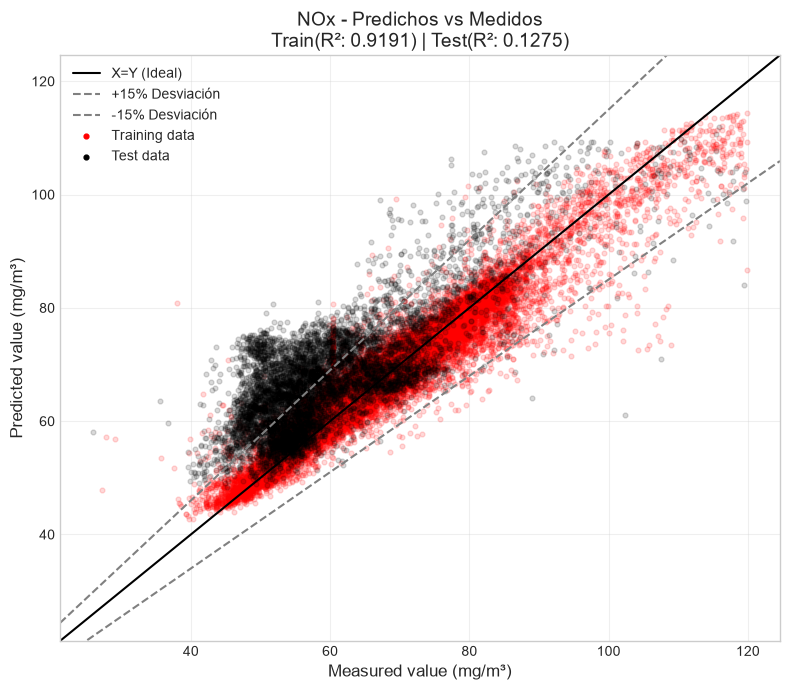


Generando gráfico: muestra del Train Set...


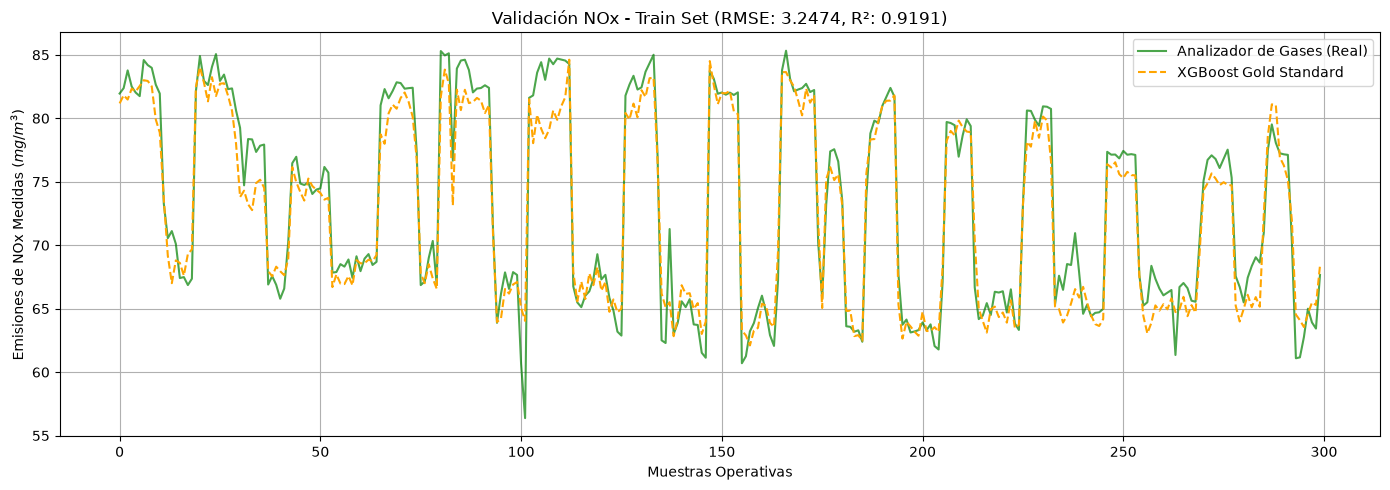


Generando gráfico: muestra del Test Set (walk-forward)...


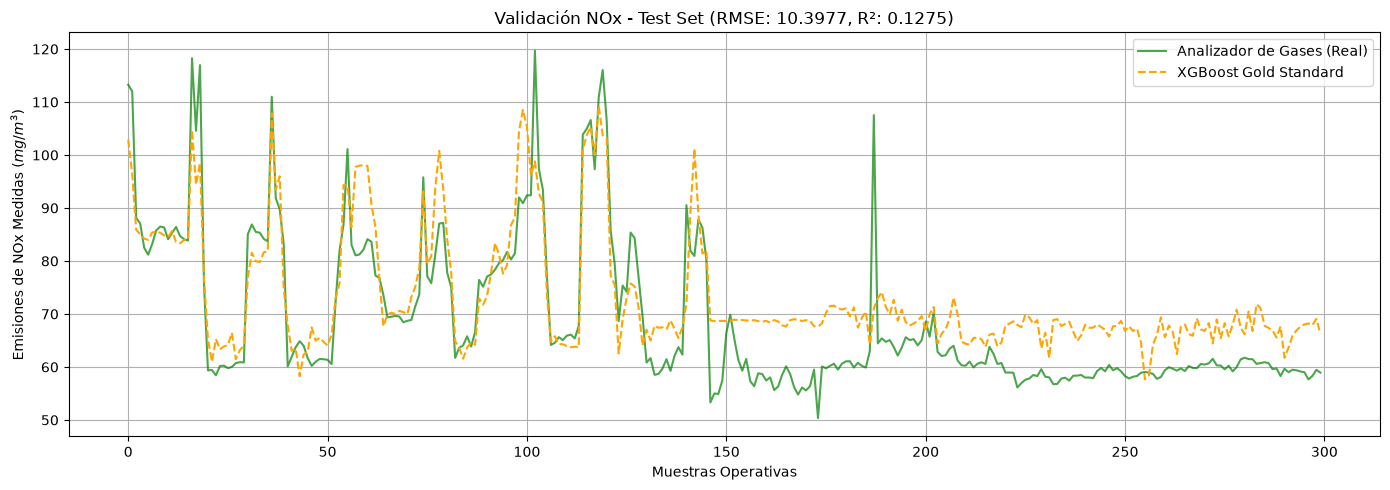

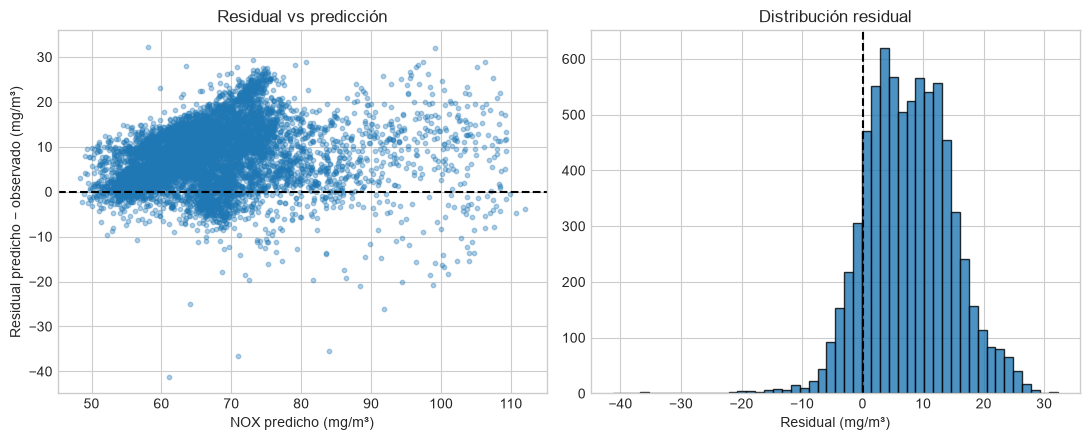

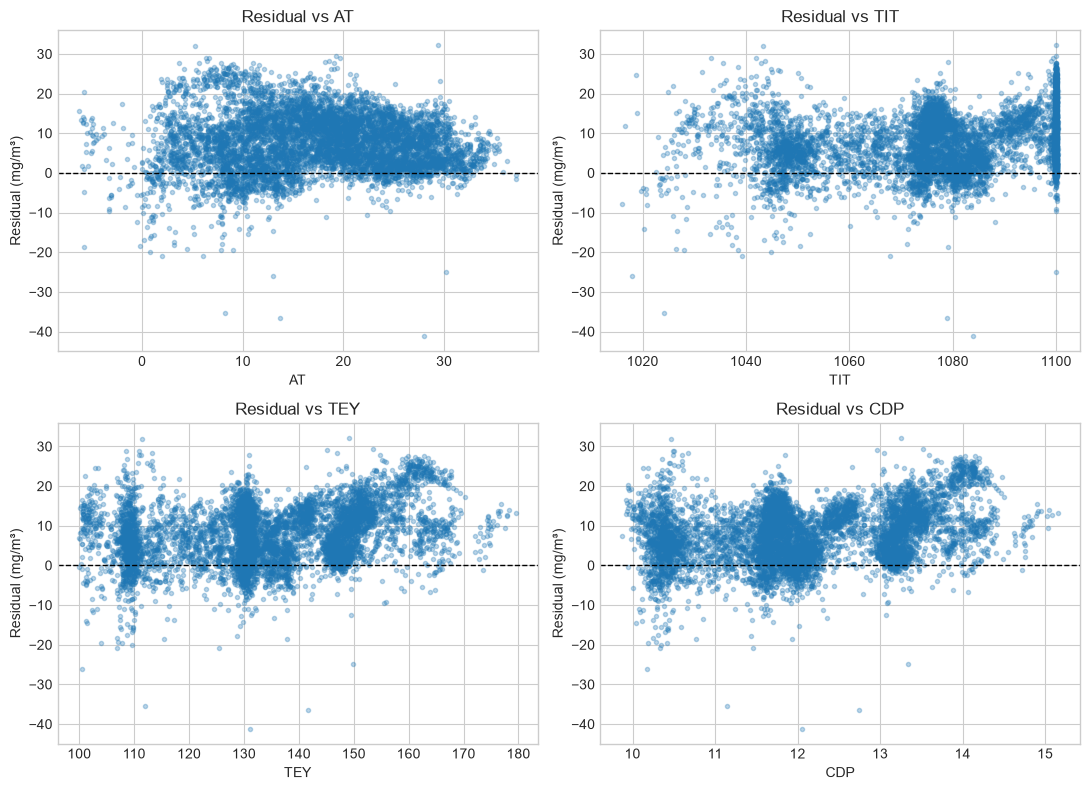

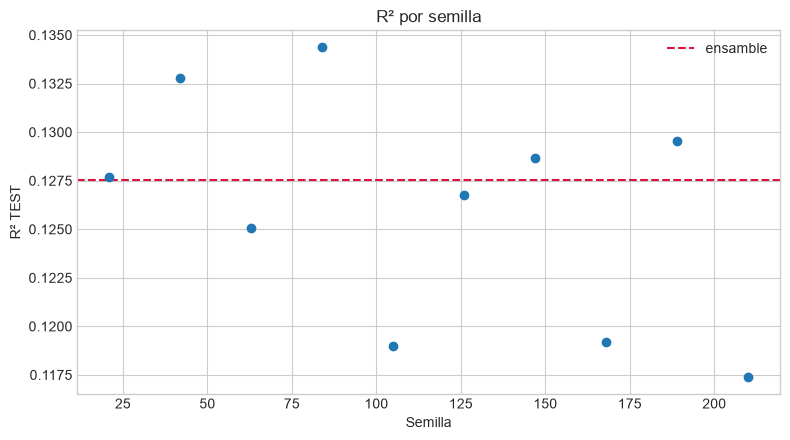

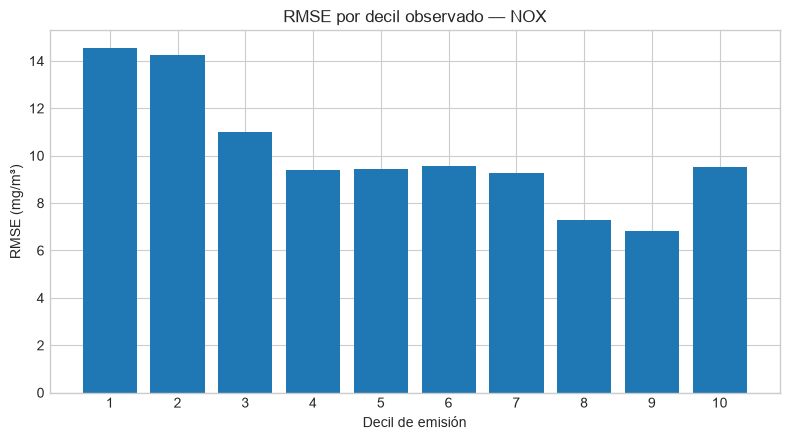

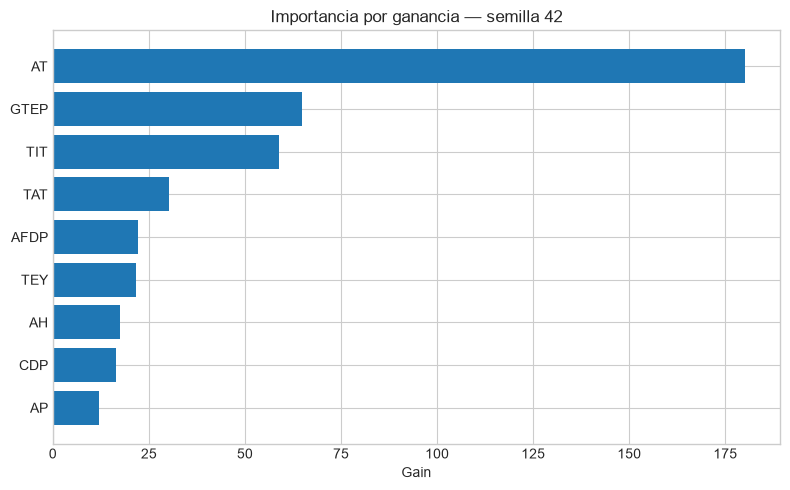

In [11]:
# [C-07.01] Figuras predictivas y de importancia
plt.style.use("seaborn-v0_8-whitegrid")


def save_figure(figure, path: Path) -> None:
    figure.tight_layout()
    figure.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()


print(f"\nGenerando gráfico combinado de predichos vs. medidos para {TARGET}...")

# DEV se incorpora únicamente para reproducir la figura histórica. No interviene
# en la evaluación TEST ni modifica modelos, árboles, semillas o configuración.
y_dev = DEV_DATA[TARGET].to_numpy(float)
dev_prediction_matrix = []
for seed in FINAL_SEEDS:
    predicted_dev_model = FINAL_MODELS[seed].predict(x_dev)
    dev_prediction_matrix.append(
        target_inverse(predicted_dev_model, target_transform)
    )
dev_ensemble = np.mean(np.vstack(dev_prediction_matrix), axis=0)
dev_ensemble_metrics = predictive_metrics(y_dev, dev_ensemble)
observed = y_test
ensemble = ENSEMBLE_PREDICTION

minimum_value = min(
    float(y_dev.min()),
    float(observed.min()),
    float(dev_ensemble.min()),
    float(ensemble.min()),
)
maximum_value = max(
    float(y_dev.max()),
    float(observed.max()),
    float(dev_ensemble.max()),
    float(ensemble.max()),
)
margin = (maximum_value - minimum_value) * 0.05
limits = [minimum_value - margin, maximum_value + margin]
limits_array = np.asarray(limits)
target_label = "NOx" if TARGET == "NOX" else TARGET

figure, axis = plt.subplots(figsize=(8, 7))
axis.plot(
    limits,
    limits,
    color="black",
    label="X=Y (Ideal)",
    linestyle="-",
    linewidth=1.5,
)
axis.plot(
    limits_array,
    limits_array * 1.15,
    color="gray",
    label="+15% Desviación",
    linestyle="--",
)
axis.plot(
    limits_array,
    limits_array * 0.85,
    color="gray",
    label="-15% Desviación",
    linestyle="--",
)
axis.scatter(
    y_dev,
    dev_ensemble,
    color="red",
    label="Training data",
    s=12,
    alpha=0.15,
)
axis.scatter(
    observed,
    ensemble,
    color="black",
    label="Test data",
    s=12,
    alpha=0.15,
)
axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
axis.set_xlim(limits)
axis.set_ylim(limits)
axis.set_title(
    f"{target_label} - Predichos vs Medidos\n"
    f"Train(R²: {dev_ensemble_metrics['R2']:.4f}) | "
    f"Test(R²: {ENSEMBLE_METRICS['R2']:.4f})",
    fontsize=14,
)
legend = axis.legend(loc="upper left", fontsize=10)
for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1.0)
axis.grid(True, alpha=0.3)
save_figure(figure, PATHS.figures_test / "01_paridad_ensamble_TEST.png")

OPERATIONAL_SAMPLE_ROWS = 300


def plot_nox_operational_sample(
    y_true: np.ndarray,
    predicted: np.ndarray,
    split_type: str,
    metrics: dict,
    output_path: Path,
) -> None:
    """Reproduce para NOx los paneles operativos DEV y TEST del referente PINN."""
    sample_rows = min(OPERATIONAL_SAMPLE_ROWS, len(y_true), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            y_true[:sample_rows],
            label="Analizador de Gases (Real)",
            color="green",
            alpha=0.7,
        )
        axis.plot(
            predicted[:sample_rows],
            label="XGBoost Gold Standard",
            color="orange",
            linestyle="dashed",
        )
        axis.set_title(
            f"Validación NOx - {split_type} "
            f"(RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f})"
        )
        axis.set_ylabel(r"Emisiones de NOx Medidas ($mg/m^3$)")
        axis.set_xlabel("Muestras Operativas")
        axis.legend()
        axis.grid(True)
        save_figure(figure, output_path)


print("\nGenerando gráfico: muestra del Train Set...")
plot_nox_operational_sample(
    y_dev,
    dev_ensemble,
    "Train Set",
    dev_ensemble_metrics,
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
)

print("\nGenerando gráfico: muestra del Test Set (walk-forward)...")
plot_nox_operational_sample(
    observed,
    ensemble,
    "Test Set",
    ENSEMBLE_METRICS,
    PATHS.figures_test / "02_serie_ensamble_TEST.png",
)

residual = ENSEMBLE_PREDICTION - y_test
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(ENSEMBLE_PREDICTION, residual, s=10, alpha=0.35)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(
    title="Residual vs predicción",
    xlabel=f"{TARGET} predicho (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axes[1].hist(residual, bins=50, edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Distribución residual", xlabel="Residual (mg/m³)")
save_figure(figure, PATHS.figures_test / "03_diagnostico_residuales_TEST.png")

key_features = ["AT", "TIT", "TEY", "CDP"] if TARGET == "NOX" else [
    "TIT", "CDP", "TEY", "TAT"
]
figure, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, feature in zip(axes.ravel(), key_features):
    axis.scatter(TEST_DATA[feature], residual, s=9, alpha=0.30)
    axis.axhline(0, color="black", linestyle="--", linewidth=1)
    axis.set(xlabel=feature, ylabel="Residual (mg/m³)", title=f"Residual vs {feature}")
save_figure(figure, PATHS.figures_test / "04_residuales_variables_operativas.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.errorbar(
    TEST_METRICS_BY_SEED.seed,
    TEST_METRICS_BY_SEED.R2,
    fmt="o",
)
axis.axhline(ENSEMBLE_METRICS["R2"], color="crimson", linestyle="--", label="ensamble")
axis.set(title="R² por semilla", xlabel="Semilla", ylabel="R² TEST")
axis.legend()
save_figure(figure, PATHS.figures_summary / "05_r2_por_semilla.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(DECILE_METRICS.decile.astype(str), DECILE_METRICS.RMSE)
axis.set(
    title=f"RMSE por decil observado — {TARGET}",
    xlabel="Decil de emisión",
    ylabel="RMSE (mg/m³)",
)
save_figure(figure, PATHS.figures_summary / "06_rmse_por_decil.png")

representative_booster = FINAL_MODELS[REPRESENTATIVE_SEED].get_booster()
gain = representative_booster.get_score(importance_type="gain")
IMPORTANCE = pd.DataFrame(
    {
        "feature": FEATURES,
        "gain": [float(gain.get(feature, 0.0)) for feature in FEATURES],
    }
).sort_values("gain", ascending=True)
atomic_csv(PATHS.tables / "feature_importance_gain_seed42.csv", IMPORTANCE)
figure, axis = plt.subplots(figsize=(8, 5))
axis.barh(IMPORTANCE.feature, IMPORTANCE.gain)
axis.set(title="Importancia por ganancia — semilla 42", xlabel="Gain")
save_figure(figure, PATHS.figures_summary / "07_importancia_gain_seed42.png")


## SEC-08 — Complejidad, almacenamiento y latencia CPU

### C-08.01 / TAB-02 / CHK-08 — Huella normalizada

Se separan árboles/nodos/hojas, UBJ desplegable, JSON diagnóstico, tamaño
total del ensamble y latencia. Un nodo no se denomina “parámetro”.


In [12]:
# [C-08.01] Complejidad estructural y benchmark CPU
def tree_depth(node: dict) -> int:
    children = node.get("children", [])
    if not children:
        return 0
    return 1 + max(tree_depth(child) for child in children)


def latency_distribution(operation, warmup: int, repetitions: int) -> dict:
    for _ in range(warmup):
        operation()
    timings = []
    for _ in range(repetitions):
        started = time.perf_counter()
        operation()
        timings.append((time.perf_counter() - started) * 1000)
    return {
        "median_ms": float(np.median(timings)),
        "p95_ms": float(np.quantile(timings, 0.95)),
        "p99_ms": float(np.quantile(timings, 0.99)),
    }


representative_path = (
    PATHS.models / f"XGBOOST_{TARGET}_WF_seed{REPRESENTATIVE_SEED}.ubj"
)
cpu_booster = xgb.Booster()
cpu_booster.load_model(representative_path)
cpu_booster.set_param({"device": "cpu", "nthread": 1})
tree_frame = cpu_booster.trees_to_dataframe()
dumps = [json.loads(item) for item in cpu_booster.get_dump(dump_format="json")]
effective_depths = [tree_depth(tree) for tree in dumps]

with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as handle:
    json_path = Path(handle.name)
try:
    cpu_booster.save_model(json_path)
    json_bytes = json_path.stat().st_size
finally:
    json_path.unlink(missing_ok=True)

x_one = TEST_DATA[FEATURES].iloc[:1].to_numpy(np.float32)
x_batch = TEST_DATA[FEATURES].to_numpy(np.float32)

def engine_operation() -> None:
    cpu_booster.inplace_predict(x_one, validate_features=False)


def end_to_end_operation() -> None:
    if not np.isfinite(x_one).all():
        raise ValueError("Entrada no finita")
    predicted_model = cpu_booster.inplace_predict(
        x_one,
        validate_features=False,
    )
    target_inverse(predicted_model, target_transform)


engine_latency = latency_distribution(
    engine_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)
end_to_end_latency = latency_distribution(
    end_to_end_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)

def batch_operation() -> None:
    cpu_booster.inplace_predict(x_batch, validate_features=False)


batch_latency = latency_distribution(
    batch_operation,
    THROUGHPUT_WARMUP,
    THROUGHPUT_REPETITIONS,
)
throughput = float(
    len(x_batch) / (batch_latency["median_ms"] / 1000)
)
ensemble_bytes = int(sum(path.stat().st_size for path in model_files))
FOOTPRINT = {
    "measurement_scope": "representative_seed_model_and_full_ensemble_storage",
    "representative_seed": REPRESENTATIVE_SEED,
    "tree_count": int(tree_frame.Tree.nunique()),
    "node_count": int(len(tree_frame)),
    "leaf_count": int(tree_frame.Feature.eq("Leaf").sum()),
    "effective_depth_max": int(max(effective_depths)),
    "effective_depth_median": float(np.median(effective_depths)),
    "configured_max_depth": int(BEST_CONFIG["xgb_parameters"]["max_depth"]),
    "serialized_ubj_mib": float(representative_path.stat().st_size / 2**20),
    "serialized_json_mib": float(json_bytes / 2**20),
    "ensemble_ubj_mib": float(ensemble_bytes / 2**20),
    "ensemble_model_count": len(FINAL_SEEDS),
    "model_storage_format": "UBJ",
    "cpu_model": platform.processor() or platform.machine(),
    "cpu_platform": platform.platform(),
    "cpu_physical_cores": psutil.cpu_count(logical=False),
    "cpu_logical_threads": psutil.cpu_count(logical=True),
    "benchmark_device": "cpu",
    "benchmark_threads": 1,
    "latency_batch_size": 1,
    "latency_warmup": LATENCY_WARMUP,
    "latency_repetitions": LATENCY_REPETITIONS,
    "throughput_warmup": THROUGHPUT_WARMUP,
    "throughput_repetitions": THROUGHPUT_REPETITIONS,
    "engine_latency_definition": "preprocessed_X_to_model_output",
    "end_to_end_latency_definition": "finite_check_model_inverse_target",
    "engine_latency_cpu_median_ms": engine_latency["median_ms"],
    "engine_latency_cpu_p95_ms": engine_latency["p95_ms"],
    "engine_latency_cpu_p99_ms": engine_latency["p99_ms"],
    "end_to_end_latency_cpu_median_ms": end_to_end_latency["median_ms"],
    "end_to_end_latency_cpu_p95_ms": end_to_end_latency["p95_ms"],
    "end_to_end_latency_cpu_p99_ms": end_to_end_latency["p99_ms"],
    "throughput_batch_rows": len(x_batch),
    "throughput_cpu_samples_per_s": throughput,
    "throughput_batch_median_ms": batch_latency["median_ms"],
    "storage_note": "UBJ and JSON are serialization sizes, not RAM",
}
FOOTPRINT_TABLE = pd.DataFrame([FOOTPRINT])
atomic_csv(PATHS.tables / "model_complexity.csv", FOOTPRINT_TABLE)
atomic_csv(PATHS.tables / "computational_footprint.csv", FOOTPRINT_TABLE)
atomic_json(PATHS.tables / "computational_footprint.json", FOOTPRINT)

separator = "=" * 68
target_label = "NOx" if TARGET == "NOX" else TARGET
print(separator)
print(f"HUELLA COMPUTACIONAL - XGBOOST {target_label} WF04 prospectivo")
print(separator)
print("Complejidad estructural")
print(f"Árboles                      : {FOOTPRINT['tree_count']:,}")
print(f"Nodos totales                : {FOOTPRINT['node_count']:,}")
print(f"Hojas totales                : {FOOTPRINT['leaf_count']:,}")
print(
    "Profundidad máxima efectiva: "
    f"{FOOTPRINT['effective_depth_max']}"
)
print(
    "Profundidad mediana efectiva: "
    f"{FOOTPRINT['effective_depth_median']:.1f}"
)
print(
    "Profundidad máxima configurada: "
    f"{FOOTPRINT['configured_max_depth']}"
)
print("Almacenamiento serializado (no equivale a RAM)")
print(
    "Modelo UBJ representativo  : "
    f"{FOOTPRINT['serialized_ubj_mib']:.6f} MiB"
)
print(
    "Modelo JSON diagnóstico    : "
    f"{FOOTPRINT['serialized_json_mib']:.6f} MiB"
)
print(
    "Ensamble UBJ (10 modelos)  : "
    f"{FOOTPRINT['ensemble_ubj_mib']:.6f} MiB"
)
print("Inferencia CPU - batch = 1")
print(f"Hilos del benchmark          : {FOOTPRINT['benchmark_threads']}")
print(f"Warm-up                      : {FOOTPRINT['latency_warmup']}")
print(f"Repeticiones                 : {FOOTPRINT['latency_repetitions']}")
print(
    "Latencia motor mediana     : "
    f"{FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia motor p95         : "
    f"{FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia motor p99         : "
    f"{FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms"
)
print(
    "Latencia end-to-end mediana: "
    f"{FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p95    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p99    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms"
)
print("Procesamiento por lotes")
print(f"Filas por lote               : {FOOTPRINT['throughput_batch_rows']:,}")
print(f"Warm-up de lotes             : {FOOTPRINT['throughput_warmup']}")
print(f"Repeticiones de lotes        : {FOOTPRINT['throughput_repetitions']}")
print(
    "Latencia mediana del lote  : "
    f"{FOOTPRINT['throughput_batch_median_ms']:.6f} ms"
)
print(
    "Throughput CPU             : "
    f"{FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s"
)
print(separator)
display(FOOTPRINT_TABLE.T.rename(columns={0: "valor"}))


HUELLA COMPUTACIONAL - XGBOOST NOx WF04 prospectivo
Complejidad estructural
Árboles                      : 1,032
Nodos totales                : 762,196
Hojas totales                : 381,614
Profundidad máxima efectiva: 15
Profundidad mediana efectiva: 15.0
Profundidad máxima configurada: 15
Almacenamiento serializado (no equivale a RAM)
Modelo UBJ representativo  : 25.364484 MiB
Modelo JSON diagnóstico    : 38.173584 MiB
Ensamble UBJ (10 modelos)  : 253.154952 MiB
Inferencia CPU - batch = 1
Hilos del benchmark          : 1
Warm-up                      : 50
Repeticiones                 : 200
Latencia motor mediana     : 0.135800 ms
Latencia motor p95         : 0.455330 ms
Latencia motor p99         : 0.678594 ms
Latencia end-to-end mediana: 0.145000 ms
Latencia end-to-end p95    : 0.318575 ms
Latencia end-to-end p99    : 0.447769 ms
Procesamiento por lotes
Filas por lote               : 7,384
Warm-up de lotes             : 10
Repeticiones de lotes        : 30
Latencia mediana del lote 

,valor
measurement_scope,representative_seed_model_and_full_ensemble_st...
representative_seed,42
tree_count,1032
node_count,762196
leaf_count,381614
effective_depth_max,15
effective_depth_median,15.0
configured_max_depth,15
serialized_ubj_mib,25.364484
serialized_json_mib,38.173584


## SEC-09 — Persistencia, manifiesto y cierre

### C-09.01 / ART-04 — Copia trazable e informe técnico

Se preservan hashes de las entradas OPT y se documentan alcance y
limitaciones antes de cerrar la evaluación.


In [13]:
# [C-09.01] Copia FROZEN e informe
source_config = FROZEN["paths"]["best_config"]
source_policy = FROZEN["paths"]["policy"]
copied_config = PATHS.configs / source_config.name
copied_policy = PATHS.configs / source_policy.name
shutil.copy2(source_config, copied_config)
shutil.copy2(source_policy, copied_policy)
if sha256_file(source_config) != sha256_file(copied_config):
    raise RuntimeError("La copia de BEST_CONFIG alteró el hash")
if sha256_file(source_policy) != sha256_file(copied_policy):
    raise RuntimeError("La copia de la política alteró el hash")

input_snapshot = {
    "status": "VERIFIED",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "protocol_notebook": PROTOCOL_NOTEBOOK_NAME,
    "opt_notebook": OPT_NOTEBOOK_NAME,
    "protocol_artifact_manifest_sha256": FROZEN["protocol_general_sha256"],
    "opt_frozen_manifest_sha256": sha256_file(FROZEN["paths"]["frozen"]),
    "config_hash": BEST_CONFIG["config_hash"],
    "campaign_fingerprint": FROZEN["campaign"]["campaign_fingerprint"],
    "study_storage_sha256": FROZEN["frozen"]["study_storage_sha256"],
    "models_reloaded_before_test": True,
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_summary_sha256": FROZEN["fold_hash"],
    "best_config_file_sha256": sha256_file(source_config),
    "training_policy_file_sha256": sha256_file(source_policy),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_file_sha256"],
}
atomic_json(PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json", input_snapshot)

report = f'''# Informe técnico — XGBoost {TARGET} walk-forward FINAL R1F_STD

## Diseño

Se consumió sin cambios la configuración {BEST_CONFIG['config_hash']} y la
política de {FINAL_N_ESTIMATORS} árboles, derivadas de WF01–WF03. Se entrenaron
diez modelos con DEV 2011–2014 completo antes de abrir 2015. El ensamble es la
media aritmética de las diez semillas predeclaradas. No se aplicaron
restricciones monotónicas, pérdida física, sintéticos, selección de variables,
escalamiento de X ni clipping.

## Resultado WF04 / 2015

- R² del ensamble: {ENSEMBLE_METRICS['R2']:.6f}.
- RMSE: {ENSEMBLE_METRICS['RMSE']:.6f} mg/m³.
- MAE: {ENSEMBLE_METRICS['MAE']:.6f} mg/m³.
- Sesgo: {ENSEMBLE_METRICS['bias']:.6f} mg/m³.
- RMSE del decil superior: {ENSEMBLE_METRICS['tail_RMSE']:.6f} mg/m³.
- Predicciones negativas: {ENSEMBLE_METRICS['negative_prediction_pct']:.6f} %.

## Complejidad

- Árboles: {FOOTPRINT['tree_count']}.
- Nodos: {FOOTPRINT['node_count']}.
- Hojas: {FOOTPRINT['leaf_count']}.
- UBJ representativo: {FOOTPRINT['serialized_ubj_mib']:.6f} MiB.
- UBJ de diez modelos: {FOOTPRINT['ensemble_ubj_mib']:.6f} MiB.
- Latencia CPU motor, batch=1: mediana=
  {FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms.
- Latencia CPU end-to-end, batch=1: mediana=
  {FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms.
- Throughput CPU sobre {FOOTPRINT['throughput_batch_rows']} filas:
  {FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s.

## Alcance

Los resultados describen transferencia prospectiva desde DEV 2011–2014 hacia
la frontera anual 2015. No demuestran desempeño fuera de ese horizonte,
relación causal ni conformidad regulatoria PEMS/CEMS/RATA.
'''
atomic_text(
    PATHS.reports / "INFORME_TECNICO_XGBOOST_NOX_WF_FINAL_R1F_STD.md",
    report,
)


### C-09.02 / ART-05 / CHK-09 — Manifiesto final y hashes

El cierre exige diez modelos, apertura única de TEST, tablas, figuras y
huella computacional. Los artefactos quedan inventariados con SHA-256.


In [14]:
# [C-09.02] Manifiesto final e inventario
required_files = [
    PATHS.audit / "ENVIRONMENT_XGBOOST_NOX_FINAL_R1F_STD.json",
    PATHS.audit / "FROZEN_INPUT_AUDIT_XGBOOST_NOX_WF_R1F.csv",
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    PATHS.audit / "PRE_TEST_GATE_R1F_STD.json",
    PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json",
    copied_config,
    copied_policy,
    PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json",
    PATHS.tables / "training_summary_by_seed.csv",
    PATHS.tables / "model_reload_audit.csv",
    PATHS.tables / "test_predictions.csv",
    PATHS.tables / "test_metrics_by_seed.csv",
    PATHS.tables / "test_metrics_ensemble.json",
    PATHS.tables / "test_summary_multiseed.csv",
    PATHS.tables / "test_metrics_by_decile.csv",
    PATHS.tables / "feature_importance_gain_seed42.csv",
    PATHS.tables / "model_complexity.csv",
    PATHS.tables / "computational_footprint.csv",
    PATHS.tables / "computational_footprint.json",
    PATHS.reports / "INFORME_TECNICO_XGBOOST_NOX_WF_FINAL_R1F_STD.md",
]
required_files.extend(model_files)
required_files.extend(metadata_files)
required_figures = [
    PATHS.figures_test / "01_paridad_ensamble_TEST.png",
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
    PATHS.figures_test / "02_serie_ensamble_TEST.png",
    PATHS.figures_test / "03_diagnostico_residuales_TEST.png",
    PATHS.figures_test / "04_residuales_variables_operativas.png",
    PATHS.figures_summary / "05_r2_por_semilla.png",
    PATHS.figures_summary / "06_rmse_por_decil.png",
    PATHS.figures_summary / "07_importancia_gain_seed42.png",
]
required_files.extend(required_figures)
missing = [str(path) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Artefactos finales ausentes: {missing}")
if (
    TEST_ACCESS_COUNT != 1
    or _TEST_HAS_BEEN_OPENED is not True
    or TEST_ACCESS_AUDIT.get("opened_once") is not True
):
    raise RuntimeError("Contrato de apertura única de TEST violado")
if model_hashes_before_test != {
    path.name: sha256_file(path) for path in model_files
}:
    raise RuntimeError("Un modelo cambió después de abrir TEST")
if metadata_hashes_before_test != {
    path.name: sha256_file(path) for path in metadata_files
}:
    raise RuntimeError("Un sidecar cambió después de abrir TEST")

ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(set(required_files))
    ]
)
atomic_csv(
    PATHS.audit / "HASHES_XGBOOST_NOX_WF_FINAL_R1F_STD.csv",
    ARTIFACT_HASHES,
)
FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "scope": "WF04 prospective annual holdout: 2011-2014 to 2015",
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebooks": [PROTOCOL_NOTEBOOK_NAME, OPT_NOTEBOOK_NAME],
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "input_contract": "WF_PROTOCOL_R1_AND_XGBOOST_NOX_WF_OPT_R1_FROZEN_ONLY",
    "protocol_artifact_manifest_sha256": FROZEN["protocol_general_sha256"],
    "opt_frozen_manifest_sha256": sha256_file(FROZEN["paths"]["frozen"]),
    "config_hash": BEST_CONFIG["config_hash"],
    "target": TARGET,
    "features": FEATURES,
    "target_transform": target_transform,
    "pure_data_driven_contract": BEST_CONFIG["pure_data_driven_contract"],
    "final_n_estimators": FINAL_N_ESTIMATORS,
    "final_seeds": FINAL_SEEDS,
    "ensemble_rule": ENSEMBLE_RULE,
    "models_frozen_before_test": True,
    "models_reloaded_before_test": True,
    "campaign_fingerprint": FROZEN["campaign"]["campaign_fingerprint"],
    "study_storage_sha256": FROZEN["frozen"]["study_storage_sha256"],
    "test_opened_once": True,
    "test_access_count": TEST_ACCESS_COUNT,
    "test_2015_sha256": TEST_ACCESS_AUDIT[
        "gt_2015_sha256_after_authorized_open"
    ],
    "dev_rows": len(DEV_DATA),
    "test_rows": len(TEST_DATA),
    "training_elapsed_seconds": FINAL_TRAINING_SECONDS,
    "ensemble_metrics": ENSEMBLE_METRICS,
    "computational_footprint": FOOTPRINT,
    "artifact_count": len(ARTIFACT_HASHES),
    "artifacts": ARTIFACT_HASHES.to_dict(orient="records"),
    "limitations": [
        "No demuestra generalización más allá de la frontera anual 2015.",
        "No demuestra extrapolación fuera del periodo observado.",
        "No equivale a certificación PEMS, RATA ni homologación regulatoria.",
    ],
}
atomic_json(
    PATHS.work / "MANIFEST_XGBOOST_NOX_WF_FINAL_R1F_STD.json",
    FINAL_MANIFEST,
)
print(
    {
        "estado": FINAL_MANIFEST["status"],
        "CHK-09": "PASS",
        "modelos": len(FINAL_SEEDS),
        "artefactos": len(ARTIFACT_HASHES),
        "TEST_abierto_una_vez": True,
        "salida": str(PATHS.work),
    }
)


{'estado': 'COMPLETE', 'CHK-09': 'PASS', 'modelos': 10, 'artefactos': 48, 'TEST_abierto_una_vez': True, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_nox_wf_final_r1f_std'}


## OUT-01 — Resumen ejecutivo

El notebook entrena diez modelos XGBoost con configuración DEV-only
congelada, cruza la puerta previa, abre 2015 una sola vez y conserva todas las
semillas en el ensamble. Las métricas caracterizan la transferencia temporal
`2011–2014 → 2015`; deben interpretarse junto con la dispersión multisemilla,
los errores por decil y la huella computacional.

## Registro de versión

**R1F_STD:** primera evaluación final XGBoost walk-forward para NOX,
estandarizada según Manual R4. Consume `WF_PROTOCOL_R1`, no reabre Optuna y
registra el hash de `gt_2015.csv` únicamente después del gate.
